In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def read_isochrone(filename, file_type):
    
    if file_type in ['txt', 'dat']:
        
        colnames = ['Zini', 'MH', 'logAge', 'Mini', 'int_IMF', 'Mass',
                    'logL', 'logTe', 'logg', 'label', 'mbolmag',
                    'Umag', 'Bmag', 'Vmag', 'Rmag', 'Imag',
                    'Jmag', 'Hmag', 'Kmag']
        
        df = pd.read_csv(filename, delim_whitespace=True, comment='#', header=None, names=colnames)
        
        log_Te = df['logTe'].to_numpy() # Effective temperature
        log_L = df['logL'].to_numpy() # Luminosity
        B_V = (df['Bmag'] - df['Vmag']).to_numpy() # color
        V = df['Vmag'].to_numpy() # magnitude
        
        return log_Te, log_L, B_V, V

In [10]:
def plot_diagrams(log_Te, log_L, B_V, V):
    
    diagrams = plt.figure(figsize=(10,5), dpi=120)
    
    # Hertzsprung-Russel diagram
    
    ax1 = diagrams.add_subplot(1,2,1)
    ax1.plot(log_Te, log_L, 'b*', label='HRD')
    ax1.invert_xaxis()
    ax1.set_xlabel(r'$\log(T_{\rm eff})$')
    ax1.set_ylabel(r'$\log(L/L_\odot)$')
    ax1.set_title('HRD')
    
    # Color-magnitude diagram
    
    ax2 = diagrams.add_subplot(1,2,2)
    ax2.plot(B_V, V, 'r*', label='CMD')
    ax2.invert_yaxis()
    ax2.set_xlabel(r'$B-V$')
    ax2.set_ylabel(r'$V$')
    ax2.set_title('CMD')
    
    plt.tight_layout()
    plt.show()

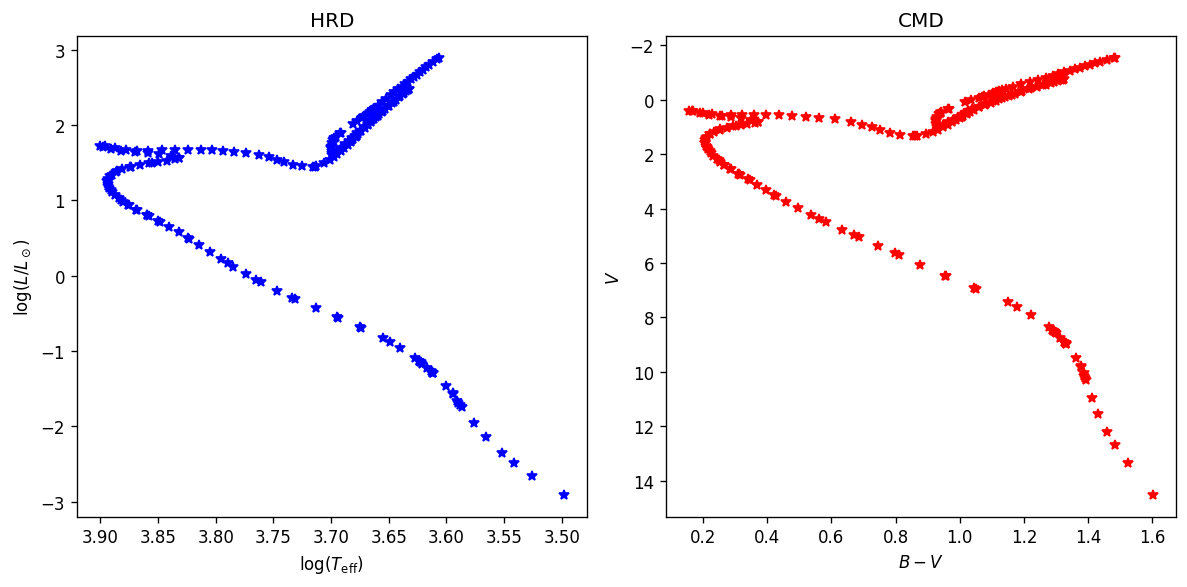

In [11]:
log_Te, log_L, B_V, V = read_isochrone('isochrone.txt', file_type='txt')
plot_diagrams(log_Te, log_L, B_V, V)